**Задача тематическое моделирование.**

Продолжаем исследование датасета с твитами.

Скачиваем датасет (источник): положительные, отрицательные.

или можно через ноутбук

!wget https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv

!wget https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv

Как альтернатива можно скачать данные из Роспотребнадзора https://zpp.rospotrebnadzor.ru/Forum/Appeals

для этого берём ноутбук parse_rospotrebnadzor.ipynb, устанавливаем количество скачанных страниц больше (не 50-сят, хотя бы 500) и для анализа берём только вопросы, так как ответы есть не всегда.

Что надо сделать:

объединить в одну выборку (это только для твитов), для роспотребнадзора сформировать датасет из вопросов;
провести исследование и выявить тематики, о которых говорят в твитах (для твитов), а для роспотребнадзора так же выявить тематики, о которых люди пишут, проанализировать;
сделать визуализацию кластеров тематик;
проинтерпритировать получившиеся тематики.

In [1]:
from google.colab import drive
drive.mount('./drive')

Drive already mounted at ./drive; to attempt to forcibly remount, call drive.mount("./drive", force_remount=True).


In [2]:
!pip3 -q install pyLDAvis

In [3]:
!pip -q freeze

absl-py==1.4.0
aiohttp==3.8.6
aiosignal==1.3.1
alabaster==0.7.13
albumentations==1.3.1
altair==4.2.2
anyio==3.7.1
appdirs==1.4.4
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array-record==0.5.0
arviz==0.15.1
astropy==5.3.4
astunparse==1.6.3
async-timeout==4.0.3
atpublic==4.0
attrs==23.1.0
audioread==3.0.1
autograd==1.6.2
Babel==2.13.1
backcall==0.2.0
beautifulsoup4==4.11.2
bidict==0.22.1
bigframes==0.13.0
bleach==6.1.0
blinker==1.4
blis==0.7.11
blosc2==2.0.0
bokeh==3.3.1
bqplot==0.12.42
branca==0.7.0
build==1.0.3
CacheControl==0.13.1
cachetools==5.3.2
catalogue==2.0.10
certifi==2023.7.22
cffi==1.16.0
chardet==5.2.0
charset-normalizer==3.3.2
chex==0.1.7
click==8.1.7
click-plugins==1.1.1
cligj==0.7.2
cloudpickle==2.2.1
cmake==3.27.7
cmdstanpy==1.2.0
colorcet==3.0.1
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.3
cons==0.4.6
contextlib2==21.6.0
contourpy==1.2.0
cryptography==41.0.5
cufflinks==0.17.3
cupy-cuda11x==11.0.0
cvxopt==1.3.2
cvxpy==1.3.2
cycler==0.12.1
cy

In [4]:
!pip -q install pymorphy2
!pip -q install pandarallel
!pip -q install -U gensim

In [5]:
import pandas as pd
import numpy as np

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import nltk
import re
from nltk.corpus import stopwords
from multiprocessing import Pool
from pymystem3 import Mystem
import pymorphy2
from pandarallel import pandarallel
from tqdm.notebook import tqdm

from gensim.models import *
from gensim import corpora

import pyLDAvis
import pyLDAvis.gensim as gensimvis

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [6]:
!wget https://disk.yandex.ru/i/v5HM-ENiGXZVpQ/negative.csv

--2023-11-27 21:05:40--  https://disk.yandex.ru/i/v5HM-ENiGXZVpQ/negative.csv
Resolving disk.yandex.ru (disk.yandex.ru)... 87.250.250.50, 2a02:6b8::2:50
Connecting to disk.yandex.ru (disk.yandex.ru)|87.250.250.50|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33638 (33K) [text/html]
Saving to: ‘negative.csv’

negative.csv        100%[===================>]  32.85K   115KB/s    in 0.3s    

2023-11-27 21:05:41 (115 KB/s) - ‘negative.csv’ saved [33638/33638]



In [7]:
!wget https://disk.yandex.ru/i/koR5eMCToCZS2Q/positive.csv

--2023-11-27 21:05:44--  https://disk.yandex.ru/i/koR5eMCToCZS2Q/positive.csv
Resolving disk.yandex.ru (disk.yandex.ru)... 87.250.250.50, 2a02:6b8::2:50
Connecting to disk.yandex.ru (disk.yandex.ru)|87.250.250.50|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33599 (33K) [text/html]
Saving to: ‘positive.csv’

positive.csv        100%[===================>]  32.81K   115KB/s    in 0.3s    

2023-11-27 21:05:45 (115 KB/s) - ‘positive.csv’ saved [33599/33599]



In [10]:
positive = pd.read_csv('/content/drive/MyDrive/positive.csv', sep=';', encoding='utf8', header=None)
positive = positive.rename(columns={3:'text'})
positive.head()

,0,1,2,text,4,5,6,7,8,9,10,11
0,408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
1,408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
2,408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0
3,408906695356973056,1386325927,ikonnikova_21,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,0,1,0,1549,19,17,0
4,408906761416867842,1386325943,JumpyAlex,@irina_dyshkant Вот что значит страшилка :D\nН...,1,0,0,0,597,16,23,1


In [11]:
negative = pd.read_csv('/content/drive/MyDrive/negative.csv', sep=';', encoding='utf8', header=None)
negative = negative.rename(columns={3:'text'})
negative.head()

,0,1,2,text,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


In [12]:
df = pd.concat([positive, negative], ignore_index=True)

In [13]:
df.tail()

,0,1,2,text,4,5,6,7,8,9,10,11
226829,425138243257253888,1390195830,Yanch_96,Но не каждый хочет что то исправлять:( http://...,-1,0,0,0,1138,32,46,0
226830,425138339503943682,1390195853,tkit_on,скучаю так :-( только @taaannyaaa вправляет мо...,-1,0,0,0,4822,38,32,0
226831,425138437684215808,1390195876,ckooker1,"Вот и в школу, в говно это идти уже надо(",-1,0,0,1,165,13,16,0
226832,425138490452344832,1390195889,LisaBeroud,"RT @_Them__: @LisaBeroud Тауриэль, не грусти :...",-1,0,1,0,2516,187,265,0
226833,425138595251625984,1390195914,sukapavlov,Такси везет меня на работу. Раздумываю приплат...,-1,0,0,0,7778,146,66,5


**Предобработка:**

Все модели, с которыми мы будем работать далее, работают с предобработанными текстами, поэтому сперва проведем стандартную предобработку текста:

In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
morph = pymorphy2.MorphAnalyzer()

In [16]:
words_regex = re.compile('\w+')

def find_words(text, regex = words_regex):
    tokens =  regex.findall(text.lower())
    return [w for w in tokens if w.isalpha() and len(w) >= 3]


stopwords_list = stopwords.words('russian')

# mystem = Mystem()
# def lemmatize(words, lemmer = mystem, stopwords = stopwords_list):
#     lemmas = lemmer.lemmatize(' '.join(words))
#     return [w for w in lemmas if not w in stopwords
#             and w.isalpha()]

def lemmatize(words, lemmer = morph, stopwords = stopwords_list):
    lemmas = [lemmer.parse(w)[0].normal_form for w in words]
    return [w for w in lemmas if not w in stopwords
            and w.isalpha()]

def preprocess(text):
    return (lemmatize(find_words(text)))

In [17]:
df.text.iloc[1]

'Да, все-таки он немного похож на него. Но мой мальчик все равно лучше:D'

In [18]:
print(preprocess(df.text.iloc[1]))

['всё', 'таки', 'немного', 'похожий', 'мальчик', 'всё', 'равно', 'хороший']


Ниже мы оставим только случайные 100,000 текстов из нашей коллекции, чтобы ускорить вычисления:

In [19]:
data = df.sample(100000)

In [20]:
# Пример параллелизации обработки текста ()
tqdm.pandas()

pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 1 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [21]:
preprocessed_text2 = data['text'].progress_apply(lambda x: preprocess(str(x)))

  0%|          | 0/100000 [00:00<?, ?it/s]

In [22]:
preprocessed_text = list(tqdm(map(preprocess, data['text']), total=len(data)))

  0%|          | 0/100000 [00:00<?, ?it/s]

In [23]:
data['text'] = preprocessed_text
data.sample(3)

,0,1,2,text,4,5,6,7,8,9,10,11
150457,413620876739756033,1387449876,kopy_you,"[последний, день, сессия, застрелить]",-1,0,0,0,213,5,9,0
71092,410473780881158144,1386699550,AntZyk,"[shemyakinandrey, понимать, поздравить, новый,...",1,0,0,0,24390,593,226,29
165895,415188566789353472,1387823642,sashabyblik,"[охох, сашка, уметь, вовремя, главное]",-1,0,0,0,2921,75,102,1


**Модель LDA.**

Воспользуемся реализацией из библиотеки gensim.

Модель использует векторное представление документов, например, мешок слов (bow), поэтому сперва создадим словарь:

In [24]:
dictionary = corpora.Dictionary(data['text'])

dictionary.filter_extremes(no_below = 10, no_above = 0.9, keep_n=None) # игнорируем слова, которые встречаются реже 10 раз или составляют более 0.9 словаря
dictionary.save('tweets.dict')

Векторизуем документы:

In [25]:
corpus = [dictionary.doc2bow(text) for text in data['text']]
corpora.MmCorpus.serialize('tweets.model', corpus)

Теперь можем обучать модель:

In [26]:
%time
lda = ldamodel.LdaModel(corpus, id2word=dictionary, num_topics=10, chunksize=50, update_every=1, passes=2)

CPU times: user 32.1 s, sys: 134 ms, total: 32.2 s
Wall time: 34.2 s


Посмотрим на получившиеся темы:

In [27]:
lda.show_topics(num_topics=10, num_words=10, formatted=True)

[(0,
  '0.124*"всё" + 0.066*"день" + 0.050*"мочь" + 0.039*"год" + 0.033*"хороший" + 0.030*"новый" + 0.023*"время" + 0.020*"дом" + 0.016*"пойти" + 0.016*"настроение"'),
 (1,
  '0.033*"мама" + 0.030*"большой" + 0.029*"час" + 0.029*"школа" + 0.027*"ходить" + 0.023*"вчера" + 0.019*"вечер" + 0.014*"домой" + 0.012*"окно" + 0.012*"рождение"'),
 (2,
  '0.106*"ещё" + 0.054*"весь" + 0.044*"свой" + 0.040*"смотреть" + 0.032*"спасибо" + 0.026*"первый" + 0.024*"написать" + 0.023*"ждать" + 0.018*"каждый" + 0.016*"скучать"'),
 (3,
  '0.043*"неделя" + 0.032*"бля" + 0.030*"казаться" + 0.029*"пара" + 0.027*"история" + 0.019*"обидно" + 0.016*"полный" + 0.015*"прям" + 0.015*"приятно" + 0.014*"настоящий"'),
 (4,
  '0.057*"человек" + 0.041*"делать" + 0.036*"который" + 0.034*"жизнь" + 0.028*"говорить" + 0.023*"наш" + 0.022*"нравиться" + 0.021*"пока" + 0.019*"купить" + 0.016*"скоро"'),
 (5,
  '0.185*"http" + 0.035*"завтра" + 0.024*"весь" + 0.022*"сказать" + 0.022*"сидеть" + 0.020*"утро" + 0.019*"друг" + 0.018*

На полученные темы можно посмотреть, изобразив их на плоскости с помощью библиотеки pyLDAvis. Чтобы спроецировать темы на плоскость, внутри применяется PCA-разложение.

In [28]:
%time
vis_data = gensimvis.prepare(lda, corpus, dictionary)
pyLDAvis.display(vis_data)

CPU times: user 6.37 s, sys: 127 ms, total: 6.5 s
Wall time: 13.8 s


Если выделять 20-ть тем, то большинство тем разговоров очень сильно пересекаются по вхождению слов и практически не разделимы. Я уменьшила число тем до 10-ти. Можно утверждать, что присутствуют следующие темы разговоров:

Отношения (дружба и любовь);

Про учебу;

Про праздники и отдых;

Про работу, учебу и плохое настроение (жалобы);

Про политику (острые темы) и жесткий юмор на злобу дня.

Посмотрим на метрики качества получившейся модели: перплексию и среднюю когерентность:

In [29]:
print(lda.log_perplexity(corpus))

-8.678993089346237


In [30]:
print('Персплексия: ', np.exp(lda.log_perplexity(corpus)))

Персплексия:  0.0001701254396932287


In [31]:
coherence_model_lda = CoherenceModel(model=lda, texts=data['text'], dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('Средняя когерентность: ', coherence_lda)

Средняя когерентность:  0.22886748224737136


Теперь можно подобрать оптимальное количество тем, опираясь на значение метрик:

  0%|          | 0/3 [00:00<?, ?it/s]

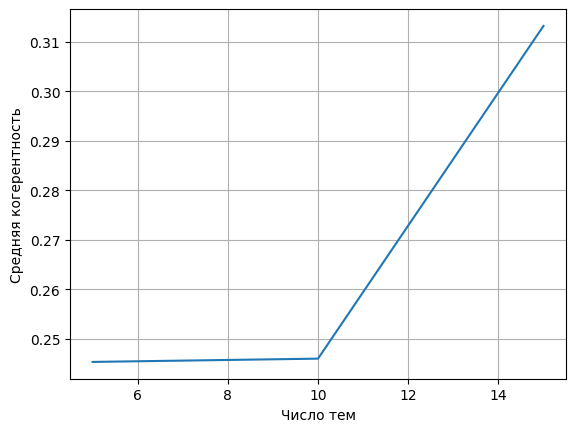

In [34]:
topics_list = [5, 10, 15]
coherences = []

for num in tqdm(topics_list):
    lda = ldamodel.LdaModel(corpus, id2word=dictionary, num_topics=num, chunksize=50, update_every=1, passes=2)
    coherences.append(CoherenceModel(model=lda, texts=data['text'], dictionary=dictionary, coherence='c_v').get_coherence())

plt.plot(topics_list, coherences)
plt.xlabel("Число тем")
plt.ylabel("Средняя когерентность")
plt.grid()
plt.show()